# Data Preparation, initial Analysis and Cleaning
Author: Vasileios Tsoumpris

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import title
import seaborn as sns
from pathlib import Path



## Reading file/s (X_train_mini.csv)

In [2]:
root = Path.cwd().parent
dataset_path_Xtrain = \
    root / 'data' / 'interim' / 'splitted' / 'X_train_mini.csv'

dataset_path_Ytrain = \
    root / 'data' / 'interim' / 'splitted' / 'y_train_mini.csv'

df = pd.read_csv(dataset_path_Xtrain)
df_y = pd.read_csv(dataset_path_Ytrain)
df = pd.concat([df, df_y], axis = "columns")

# rows and columns
print("The dataset contains ", df.shape[0], " rows and ", df.shape[1], " features.")
df.head()

The dataset contains  65129  rows and  50  features.


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,146463126,23312916,AfricanAmerican,Female,[40-50),?,1,3,5,8,...,No,Steady,No,No,No,No,No,No,Yes,NO
1,42768240,888327,Caucasian,Female,[60-70),?,1,1,7,2,...,No,No,No,No,No,No,No,No,No,NO
2,288867768,45861579,Caucasian,Female,[60-70),?,2,1,7,13,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,79126704,383058,AfricanAmerican,Female,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
4,214896840,38385846,Caucasian,Male,[80-90),?,1,3,7,4,...,No,Down,No,No,No,No,No,Ch,Yes,<30


## Data Analysis and Initial Cleaning of Data

### Initial Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65129 entries, 0 to 65128
Data columns (total 50 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   encounter_id              65129 non-null  int64
 1   patient_nbr               65129 non-null  int64
 2   race                      65129 non-null  str  
 3   gender                    65129 non-null  str  
 4   age                       65129 non-null  str  
 5   weight                    65129 non-null  str  
 6   admission_type_id         65129 non-null  int64
 7   discharge_disposition_id  65129 non-null  int64
 8   admission_source_id       65129 non-null  int64
 9   time_in_hospital          65129 non-null  int64
 10  payer_code                65129 non-null  str  
 11  medical_specialty         65129 non-null  str  
 12  num_lab_procedures        65129 non-null  int64
 13  num_procedures            65129 non-null  int64
 14  num_medications           65129 non-null  int64
 

**max_glu_serum** and **A1Cresult** have many **Nan** values. We should address them as they may be important for predicting the outcome.

### 1. Is there any encounter_id that is repeated?

In [4]:
# the question is:
# Any patient who has readmitted multiple times?
df["encounter_id"].duplicated(keep = False).unique()

array([False])

Only one unique value (False) indicating that there are no duplicate encounter_ids.

### 2. Is there any patient who has readmitted multiple times?

In [5]:
print("Distinct number of patients: ",
      df["patient_nbr"].value_counts().shape[0])
df["patient_nbr"].value_counts().head(10)
# or use this (it is the same):
# df[["patient_nbr"]].groupby("patient_nbr").size().sort_values(ascending=False).head(10)

Distinct number of patients:  50322


patient_nbr
88785891     25
1660293      21
43140906     19
92709351     18
84348792     15
88681950     15
23643405     15
106757478    14
88789707     14
41617368     14
Name: count, dtype: int64

There are multiple patients who have been readmitted multiple times.

What should we do with these patients?

### 3. How many unique values in demographic features are there?
(features: gender, race, age)

Function used

In [6]:
def analyse_unique_values(dfr, column_name, plot_bar = True):
    """ Analyse unique values and NAs in a feature."""

    # count the number of unique values in the feature
    analysis_df = dfr[[column_name]].groupby(column_name).size().sort_values(ascending=False)
    # draft a plot of the number of unique values (horizontal bar chart)
    if plot_bar:
        analysis_df.plot(kind = 'barh',
                         title = f'Number of encounters {column_name}',
                         xlabel = 'Count of instances',
                         )
    # identify any NA values
    # find any NA values in the feature,
    # and if exist return True, else False
    has_na = dfr[column_name].isna().any()
    # count the number of NA values
    count_na = dfr[column_name].isna().sum()
    # print the results for NA analysis
    print(f'NAs identified in feature:'
          f'{column_name} with a count of {count_na}' if has_na
          else f'No NAs identified in {column_name} (count = {count_na})' ,)

    print(analysis_df)

    return analysis_df

#### Race

No NAs identified in race (count = 0)
race
Caucasian          48773
AfricanAmerican    12244
?                   1426
Hispanic            1315
Other                948
Asian                423
dtype: int64


race
Caucasian          48773
AfricanAmerican    12244
?                   1426
Hispanic            1315
Other                948
Asian                423
dtype: int64

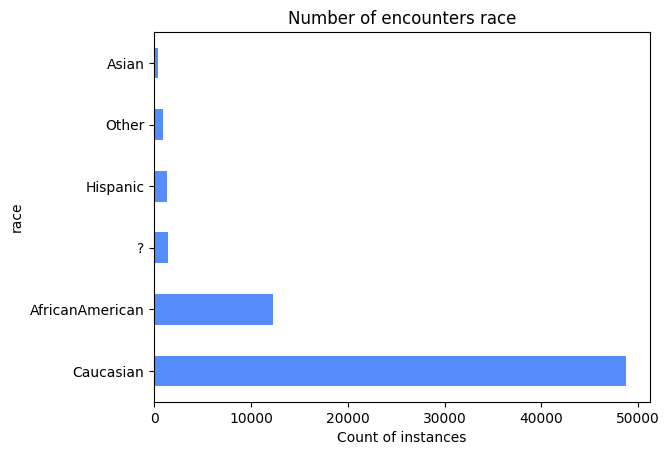

In [7]:
analyse_unique_values(dfr = df, column_name = 'race')

Found the '?' which is likely a placeholder for missing data. How should we handle this?

A possible strategy is to convert to 'Unknown'.

#### Gender

No NAs identified in gender (count = 0)
gender
Female             35098
Male               30028
Unknown/Invalid        3
dtype: int64


gender
Female             35098
Male               30028
Unknown/Invalid        3
dtype: int64

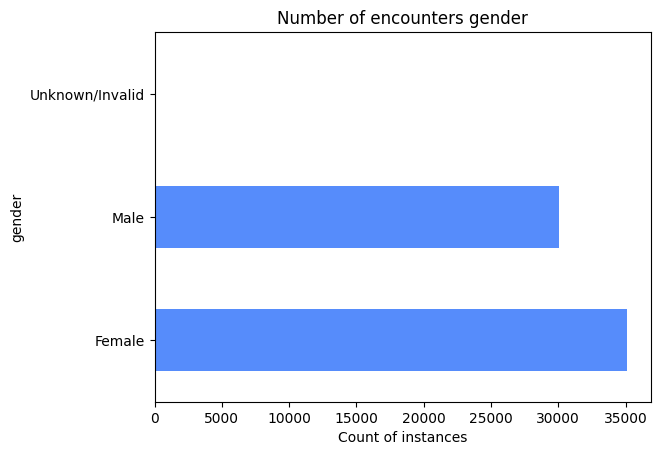

In [8]:
analyse_unique_values(dfr = df, column_name = 'gender')

An imputation strategy is possible for **gender** feature.

#### Age

No NAs identified in age (count = 0)
age
[70-80)     16687
[60-70)     14440
[50-60)     11104
[80-90)     10903
[40-50)      6181
[30-40)      2415
[90-100)     1786
[20-30)      1073
[10-20)       448
[0-10)         92
dtype: int64


age
[70-80)     16687
[60-70)     14440
[50-60)     11104
[80-90)     10903
[40-50)      6181
[30-40)      2415
[90-100)     1786
[20-30)      1073
[10-20)       448
[0-10)         92
dtype: int64

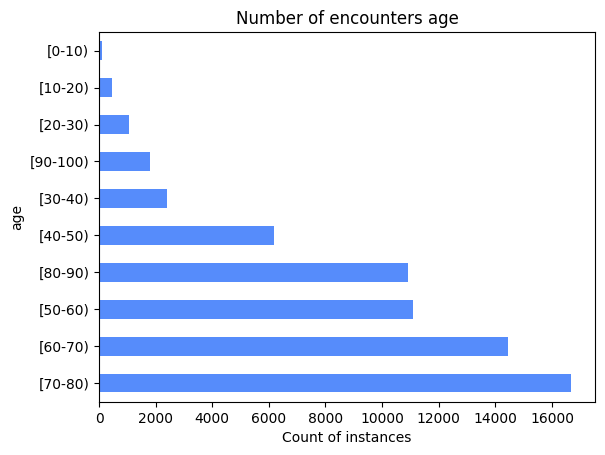

In [9]:
analyse_unique_values(dfr = df, column_name = 'age')

Age feature has no missing values.

### 5. What about the feature of **weight**?

No NAs identified in weight (count = 0)
weight
?            63024
[75-100)       873
[50-75)        606
[100-125)      405
[125-150)      102
[25-50)         58
[0-25)          34
[150-175)       21
[175-200)        4
>200             2
dtype: int64


weight
?            63024
[75-100)       873
[50-75)        606
[100-125)      405
[125-150)      102
[25-50)         58
[0-25)          34
[150-175)       21
[175-200)        4
>200             2
dtype: int64

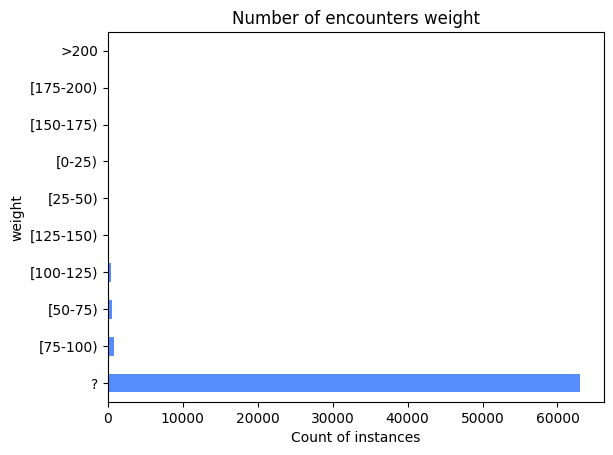

In [10]:
analyse_unique_values(df, 'weight')

This feature has many '?' values. We should consider adding this feature later on our model as it may be important for predicting the outcome. On the other hand the majority of the values are '?'.

### Additional analysis of the dataframes' numeric features is required.

In [11]:
numeric_feats_analysis = \
df.describe().drop( # dropping the numeric indexes
    columns = ['encounter_id',
              'patient_nbr',
              'admission_type_id',
               'admission_source_id',
              'discharge_disposition_id'
               ])
# print results as a dataframe
numeric_feats_analysis

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,65129.000000,65129.000000,65129.000000,65129.000000,65129.000000,65129.000000,65129.000000,65129.000000
mean,4.402463,43.056657,1.344624,16.020053,0.371355,0.195520,0.635078,7.419767
std,2.988536,19.727165,1.708065,8.117016,1.267988,0.914609,1.267888,1.935234
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,14.000000,132.000000,6.000000,75.000000,42.000000,64.000000,21.000000,16.000000


There are no Nans or negative values in the numeric features above, meaning that we can transform them with no problem.
Specifically, we may use **MinMaxScaler** or **StandardScaler** (z-score) to transform these numeric features.

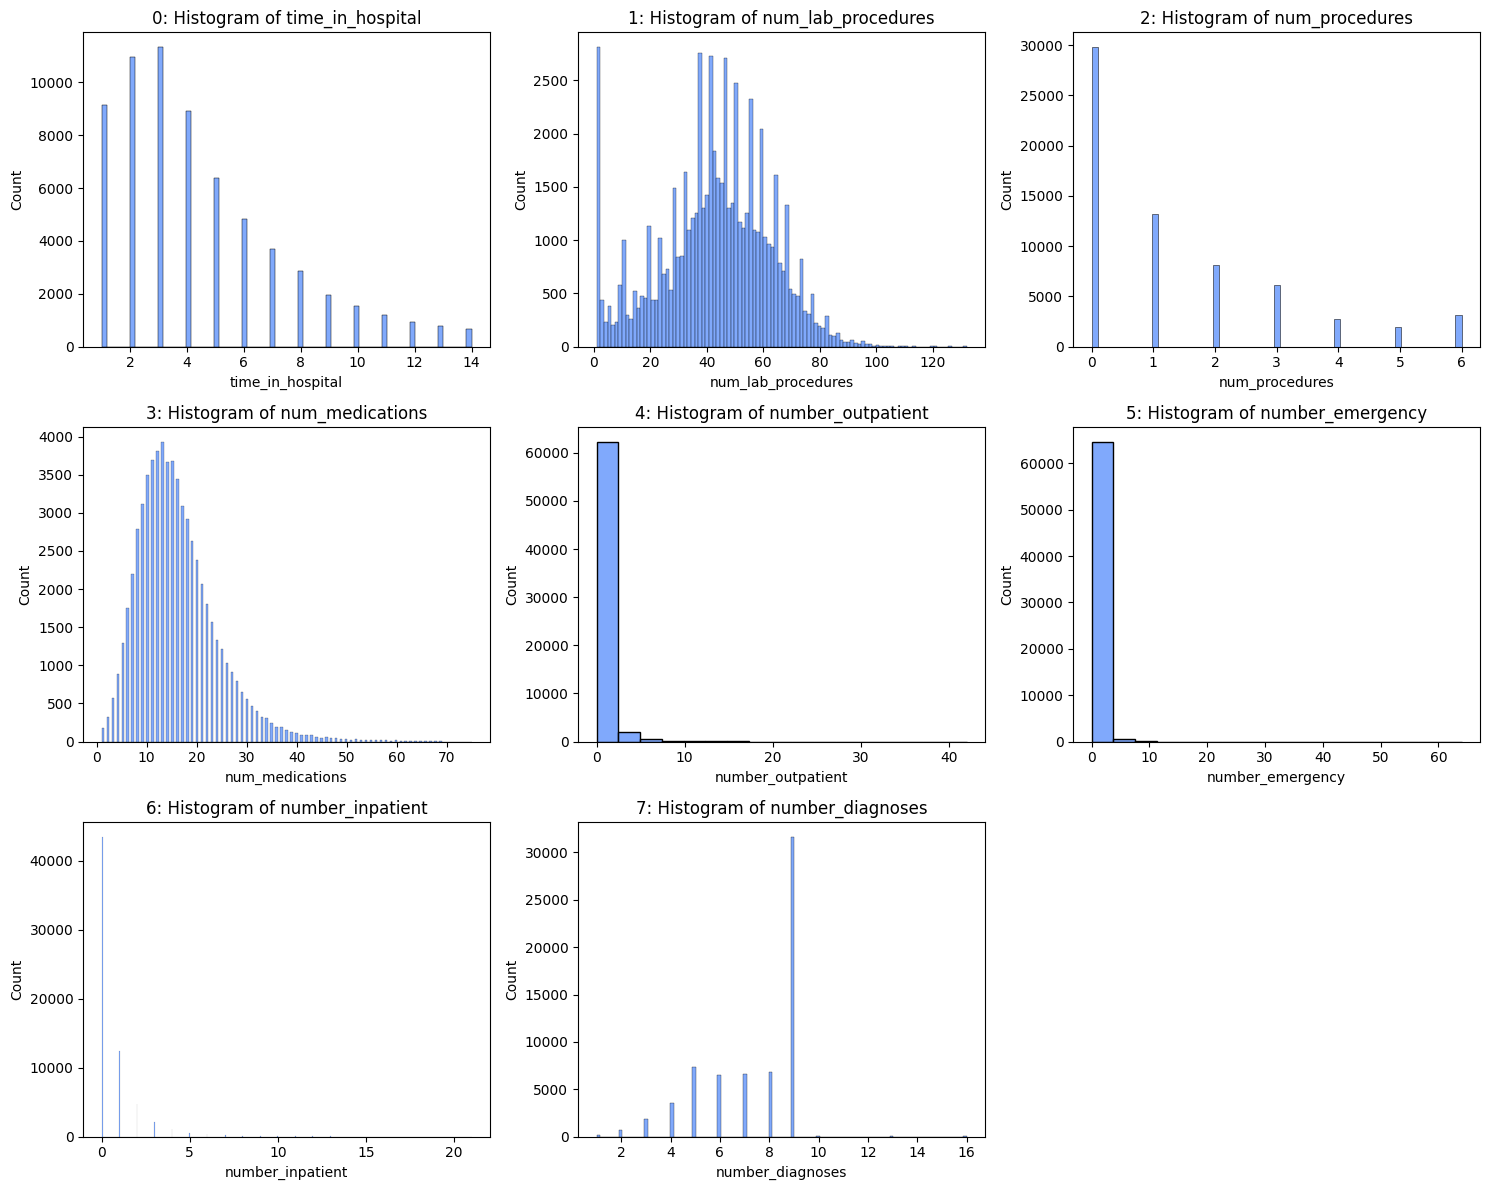

In [13]:
def plot_histograms(dfr,
                    numeric_features
                    ):

    # Assuming 'df' is your DataFrame and 'numeric_feats_analysis' is defined
    # numeric_feats = numeric_feats_analysis.columns.to_list()
    n_feats = len(numeric_features)

    # calculating the number of rows needed for 3 columns
    n_rows = int(np.ceil(n_feats / 3))

    # create subplots using a grid layout
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))

    # flatten the axes array for easy iteration
    axes = axes.flatten()
    # iterate over the chosen features and plot the histograms
    for i, column in enumerate(numeric_features):
        sns.histplot(dfr[column], ax=axes[i])
        axes[i].set_title(f'{i}: Histogram of {column}')
    # Hide any unused subplots
    for j in range(n_feats, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


plot_histograms(df,
                numeric_feats_analysis.columns.to_list()
                )
